In [1]:
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices, price_data
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.hdo import create_hdo_system
from lignin_saf.systems.cellulosic_ethanol_no_preatreatment import create_cellulosic_ethanol_system
from atj_saf.atj_bst.etj_ligfirst import create_etj_system_no_facilities
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from lignin_saf.ligsaf_units import HydrogenStorageTank




chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7   # 2016 USD basis

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()

# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_CRUDE_OUT)
monomer_purification_sys = create_monomer_purification_system(ins=F.PURE_OIL_OUT)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

# ── Area 400: Hydrodeoxygenation ───────────────────────────────────────────
hdo_system = create_hdo_system(ins=F.MON_MONOMERS_OUT)
hdo_system.simulate()

etoh_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp, add_denaturant=False)
etoh_system.simulate()

# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.
etoh_ww     = [F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

# Removing the NH3 fraction of the ethanol output - in the future CBP will remove this anyways, so I've just modelled it as a splitter
nh3_splitter = bst.units.Splitter(ins = F.T703.outs[0], split = {'NH3':1.0} )
nh3_splitter.simulate()

# Ethanol to Jet system
etj_system = create_etj_system_no_facilities(ins = nh3_splitter.outs[1])
etj_system.simulate()


WWT = bst.create_conventional_wastewater_treatment_system('WWT', ins=[F.WW_10, F.WastePulp, F.RCF_WW_OUTS, F.WW_11, F.WW_12, F.HDO_WW, F.HDO_wash_water, F.ETJ_WW_OUTS] + etoh_ww)

for unit in WWT.units:
    if hasattr(unit, 'strict_moisture_content'):
        unit.strict_moisture_content = False

F.unit.PWC.ins[0] = WWT.outs[2]

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)


BT = bst.facilities.BoilerTurbogenerator('BT', fuel_price=prices['CH4'])


gas_mixer= bst.Mixer('MIX_BT_gas', ins=(WWT.outs[0], F.RCF_PSAWASTE_OUTS, F.HDO_purge_gases, F.ETJ_PSAWASTE_OUTS))

BT.ins[0] = solids_to_BT.outs[0]  # Connecting sludge to BT solids feed
BT.ins[1] = gas_mixer.outs[0]   # Connecting biogas from WW treatment and PSA waste gases from RCF


combined_saf = bst.units.Mixer(ins = (F.ETJ_SAF_OUT, F.HDO_CYCLOALKANES_OUT), outs = 'TOTAL_SAF', rigorous = True)

h2_rcf = bst.Stream()
h2_rcf.copy_like(F.RCF_H2_IN)

h2_hdo = bst.Stream()
h2_hdo.copy_like(F.HDO_H2_IN)

h2_etj = bst.Stream()
h2_etj.copy_like(F.ETJ_H2_IN)

# Shared H2 storage — sized from combined ETJ + HDO fresh H2 demand
h2_feed_mixer = bst.Mixer('H2_FEED_MIX', ins=(h2_rcf, h2_hdo, h2_etj))
shared_h2_storage = HydrogenStorageTank('H2_TK', ins=h2_feed_mixer.outs[0])


rcf_pure_mon_hdo_etoh_etj_system = bst.System(
    'RCF+HDO+Cellulosic_ETJ',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, hdo_system, etoh_system, etj_system, combined_saf, WWT),
    facilities=[solids_to_BT, gas_mixer, h2_feed_mixer, shared_h2_storage, BT],
)

rcf_pure_mon_hdo_etoh_etj_system.simulate()

F.ETJ_H2_IN.price = price_data['hydrogen']   # 8.46 USD/kg
F.ETJ_RN_OUT.price = price_data['renewable_naphtha']   # 0.71 USD/kg
F.ETJ_RD_OUT.price = price_data['renewable_diesel']    # 1.888 USD/kg





integrated_tea = create_cellulosic_ethanol_tea(rcf_pure_mon_hdo_etoh_etj_system)
mjsp = round(((integrated_tea.solve_price(F.TOTAL_SAF)*F.TOTAL_SAF.rho)/264.172),2)

print(f'The MSP for SAF blend is  {mjsp} USD/gal')



c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\dew_point.py:129: RuntimeWarning: Methane has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.45e+03 hp), head (3.36e+03 ft), kinematic viscosity (5.99e-07 m2/s), and NPSH (4.21 ft); assuming centrigugal pump
  warn(f'{repr(

The MSP for SAF blend is  30.58 USD/gal


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostWarning: <IsentropicCompressor: RCF_COMP1> power (1.487e-11 hp) is out of bounds (10 to 750 hp) for cost correlation
  self._cost(**cost_kwargs) if cost_kwargs else self._cost()
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:986: RuntimeWarning: the purchase cost item, 'Total Cost', has no defined bare-module factor in the 'HydrogenStorageTank.F_BM' dictionary; bare-module factor now has a default value of 1
  warn(f"the purchase cost item, '{name}', has "


Font: Arial
Done.


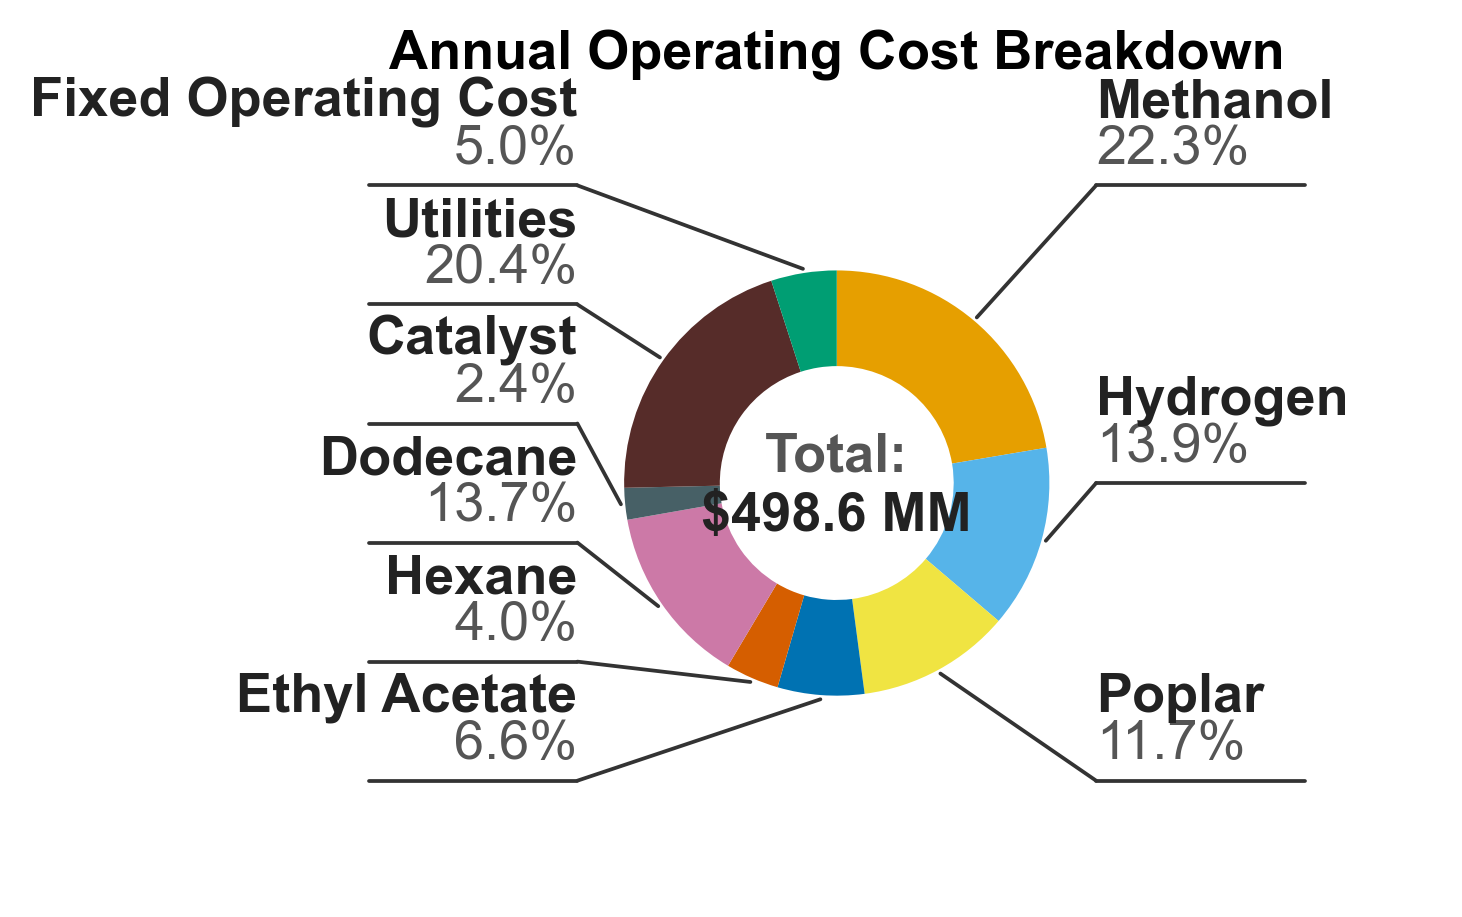

In [11]:
# Operating costs plot
methanol_price = F.RCF_MEOH_IN.F_mass * prices['Methanol'] * integrated_tea.operating_hours
hydrogen_price = (F.RCF_H2_IN.F_mass + F.HDO_H2_IN.F_mass + F.ETJ_H2_IN.F_mass) * prices['Hydrogen'] * integrated_tea.operating_hours
poplar_price = F.Poplar_In.F_mass * prices['Feedstock'] * integrated_tea.operating_hours
ethyl_acetate_price = F.EthylAcetate_in.F_mass * prices['EthylAcetate'] * integrated_tea.operating_hours
hexane_price = F.Hexane_In.F_mass * prices['Hexane'] * integrated_tea.operating_hours
dodecane_price = F.HDO_DODECANE_IN.F_mass * prices['Dodecane'] * integrated_tea.operating_hours
catalyst = (
    F.RCF_CAT_IN.F_mass * prices['NiC_catalyst']
    + F.HDO_CAT_IN.F_mass * prices['HDO_Cat']
    + F.Dehyd_cat_replacement.F_mass * price_data['dehydration_catalyst']
    + F.Olig_cat_replacement.F_mass * price_data['oligomerization_catalyst']
    + F.Hydgn_cat_replacement.F_mass * price_data['hydrogenation_catalyst']
) * integrated_tea.operating_hours

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# ── Font ──────────────────────────────────────────────────────────────────────
font_pref = ["Arial", "Liberation Sans", "DejaVu Sans"]
available = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
chosen = next((f for f in font_pref if f in available), "DejaVu Sans")
print(f"Font: {chosen}")

plt.rcParams.update({
    "font.family": chosen,
    "mathtext.fontset": "custom",
    "mathtext.rm": chosen,
    "mathtext.it": chosen,
    "mathtext.bf": chosen,
})
plt.rcParams['svg.fonttype'] = 'none'

oi_colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#476066",  # dark teal
    "#562C29",  # dark brown
    "#009E73",  # bluish green
]

categories = [
    "Methanol",
    "Hydrogen",
    "Poplar",
    "Ethyl Acetate",
    "Hexane",
    "Dodecane",
    "Catalyst",
    "Utilities",
    "Fixed Operating Cost",
]

values = [
    methanol_price,
    hydrogen_price,
    poplar_price,
    ethyl_acetate_price,
    hexane_price,
    dodecane_price,
    catalyst,
    integrated_tea.utility_cost,
    integrated_tea.FOC,
]

# ── Figure ────────────────────────────────────────────────────────────────────
DPI      = 300
fig_w_in = 1500 / DPI
fig_h_in = 1260 / DPI

FS_TITLE  = 13
FS_TOTAL  = 13
FS_PCT    = 13

DONUT_WIDTH = 0.45

fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

# ── draw_donut ────────────────────────────────────────────────────────────────
def draw_donut(ax, vals, title):
    total = sum(vals)
    fracs = [v / total for v in vals]
    n = len(vals)

    wedges, _ = ax.pie(
        vals,
        colors=oi_colors[:n],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(
            width=DONUT_WIDTH,
            linewidth=0,
            edgecolor="none",
        ),
    )

    # ── Center label ──────────────────────────────────────────────────────
    ax.text(0,  0.12, "Total:",
            ha="center", va="center",
            fontsize=FS_TOTAL, fontweight="bold", color="#555555")
    ax.text(0, -0.16,
            f"${total/1e6:.1f} MM",
            ha="center", va="center",
            fontsize=FS_TOTAL, fontweight="bold", color="#222222")

    r_outer = 1.0

    # ── Collect label info ────────────────────────────────────────────────
    label_info = []
    for i, (wedge, frac) in enumerate(zip(wedges, fracs)):
        pct   = frac * 100
        theta = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)
        label_info.append({
            "theta":    theta,
            "pct":      pct,
            "cat":      categories[i],
            "is_right": np.cos(theta) >= 0,
        })

    # ── Split left/right, sorted top → bottom ────────────────────────────
    right = sorted([d for d in label_info if     d["is_right"]],
                   key=lambda d: np.sin(d["theta"]), reverse=True)
    left  = sorted([d for d in label_info if not d["is_right"]],
                   key=lambda d: np.sin(d["theta"]), reverse=True)

    # ── Evenly distribute y positions on each side ────────────────────────
    Y_TOP, Y_BOT = 1.40, -1.40

    def y_positions(n_labels):
        return list(np.linspace(Y_TOP, Y_BOT, n_labels)) if n_labels > 1 else [0.0]

    right_ys = y_positions(len(right))
    left_ys  = y_positions(len(left))

    # ── Fixed x anchors ───────────────────────────────────────────────────
    X_R_CONN, X_R_FAR = 1.22,  2.20
    X_L_CONN, X_L_FAR = -1.22, -2.20

    GAP    = 0.05   # gap between underline and bottom of percentage text
    LINE_H = 0.22   # vertical step from percentage to category name

    def draw_group(group, ys, is_right):
        x_conn = X_R_CONN if is_right else X_L_CONN
        x_far  = X_R_FAR  if is_right else X_L_FAR
        ha     = "left"   if is_right else "right"

        for d, y_line in zip(group, ys):
            theta = d["theta"]
            pct   = d["pct"]
            cat   = d["cat"]

            # Start just outside the outer ring
            x0 = (r_outer + 0.02) * np.cos(theta)
            y0 = (r_outer + 0.02) * np.sin(theta)

            # Diagonal leader line
            ax.plot([x0, x_conn], [y0, y_line],
                    color="#333333", lw=0.9, solid_capstyle="round",
                    clip_on=False, zorder=5)

            # Horizontal underline
            ax.plot([x_conn, x_far], [y_line, y_line],
                    color="#333333", lw=0.9, solid_capstyle="round",
                    clip_on=False, zorder=5)

            # Percentage just above underline
            ax.text(x_conn, y_line + GAP,
                    f"{pct:.1f}%",
                    ha=ha, va="bottom",
                    fontsize=FS_PCT,
                    color="#555555",
                    clip_on=False)

            # Category name bold, above percentage
            ax.text(x_conn, y_line + GAP + LINE_H,
                    cat,
                    ha=ha, va="bottom",
                    fontsize=FS_PCT,
                    fontweight="bold",
                    color="#222222",
                    clip_on=False)

    draw_group(right, right_ys, is_right=True)
    draw_group(left,  left_ys,  is_right=False)

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=10)
    ax.set_xlim(-2.8, 2.8)
    ax.set_ylim(-1.9, 1.75)


draw_donut(ax, values, "Annual Operating Cost Breakdown")

plt.rcParams['svg.fonttype'] = 'none'
fig.tight_layout(rect=[0, 0.02, 1, 1])

fig.savefig("operating_breakdown_2.svg", format="svg", bbox_inches="tight")
print("Done.")

In [ ]:
(712/1000) * 1.35 * (226.6/285.6) 

0.7626327731092437

In [ ]:
fig.show()

C:\Users\hwadg\AppData\Local\Temp\ipykernel_30976\89474557.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
